# NutriVision AI

## Dataset Exploration (Food-101)

### Objective

This notebook explores the Food-101 dataset before preprocessing and model development.

The following analyses are performed:

- Load the dataset
- Verify folder structure
- Count food classes
- Count total images
- Check class distribution
- Display random food images
- Analyze image dimensions
- Detect corrupted images

This notebook forms the foundation for all subsequent preprocessing and model training steps.

#Import Libraries
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

In [2]:
#Import Libraries
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

In [3]:
# -------------------------------
# Project Configuration
# -------------------------------

PROJECT_PATH = Path(r"D:\projects\NutriVision-AI")

DATASET_PATH = PROJECT_PATH / "data" / "raw" / "food-101" / "images"

OUTPUT_PATH = PROJECT_PATH / "outputs"

PLOTS_PATH = OUTPUT_PATH / "plots"

METRICS_PATH = OUTPUT_PATH / "metrics"

RANDOM_STATE = 42

random.seed(RANDOM_STATE)

print("Dataset Path :", DATASET_PATH)

Dataset Path : D:\projects\NutriVision-AI\data\raw\food-101\images


In [4]:
#Verify Dataset
if DATASET_PATH.exists():
    print("Dataset Found")
else:
    print("Dataset NOT Found")

Dataset Found


In [5]:
#Load Classes
classes = sorted([
    folder.name
    for folder in DATASET_PATH.iterdir()
    if folder.is_dir()
])

print(f"Number of Classes : {len(classes)}")

Number of Classes : 101


In [6]:
#Images Per Class
image_counts = {}

total_images = 0

for food_class in classes:

    image_folder = DATASET_PATH / food_class

    count = len(list(image_folder.glob("*.jpg")))

    image_counts[food_class] = count

    total_images += count

print("Total Images :", total_images)

Total Images : 101000


In [7]:
#DataFrame
df = pd.DataFrame({
    "Food Class": image_counts.keys(),
    "Number of Images": image_counts.values()
})

df.head()

,Food Class,Number of Images
0,apple_pie,1000
1,baby_back_ribs,1000
2,baklava,1000
3,beef_carpaccio,1000
4,beef_tartare,1000


In [8]:
#Dataset Statistics
print(df.describe())

       Number of Images
count             101.0
mean             1000.0
std                 0.0
min              1000.0
25%              1000.0
50%              1000.0
75%              1000.0
max              1000.0


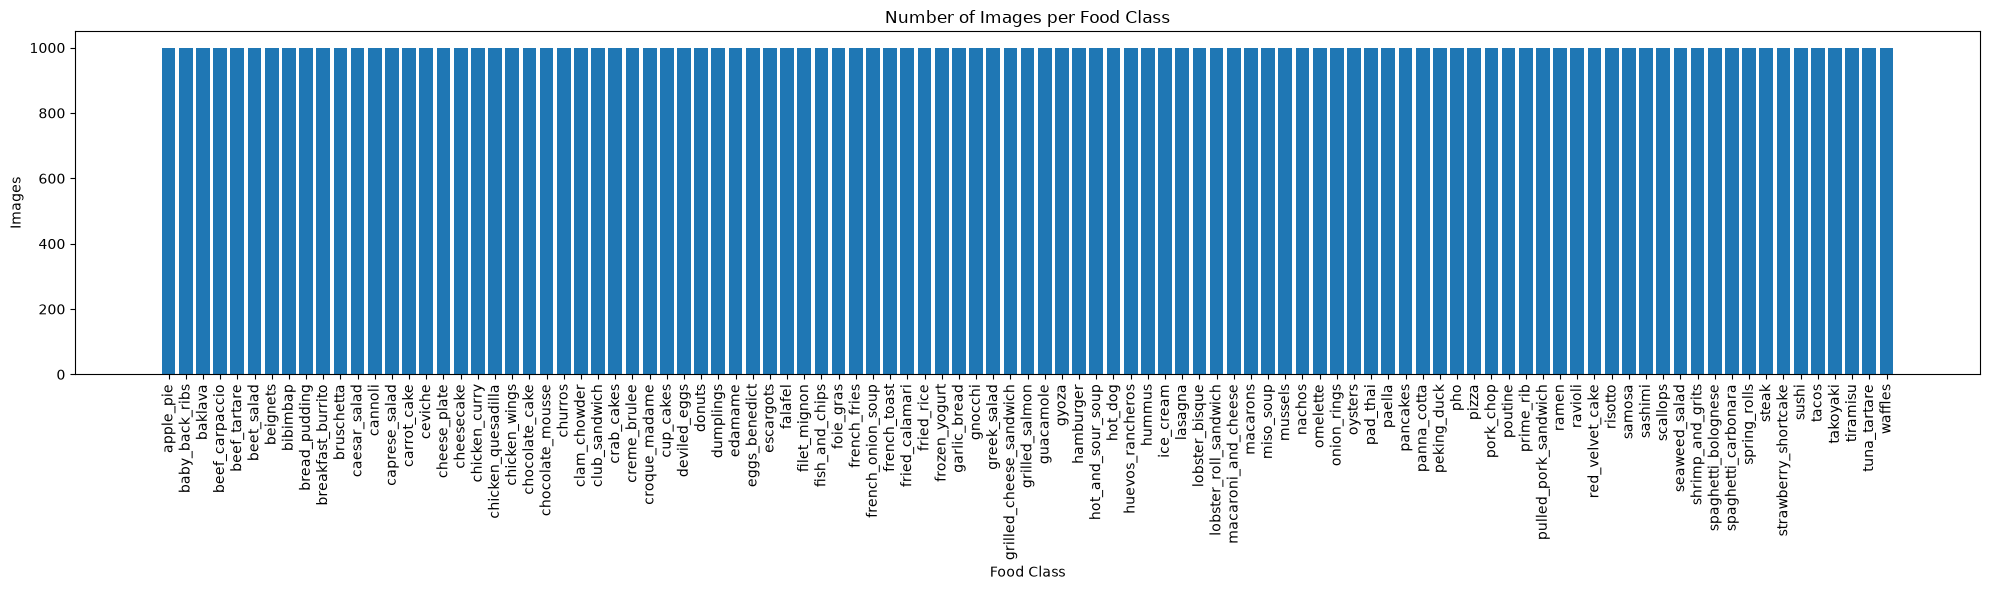

In [9]:
#Class Distribution
plt.figure(figsize=(20,6))

plt.bar(
    df["Food Class"],
    df["Number of Images"]
)

plt.xticks(rotation=90)

plt.title("Number of Images per Food Class")

plt.xlabel("Food Class")

plt.ylabel("Images")

plt.tight_layout()

plt.savefig(PLOTS_PATH / "class_distribution.png")

plt.show()

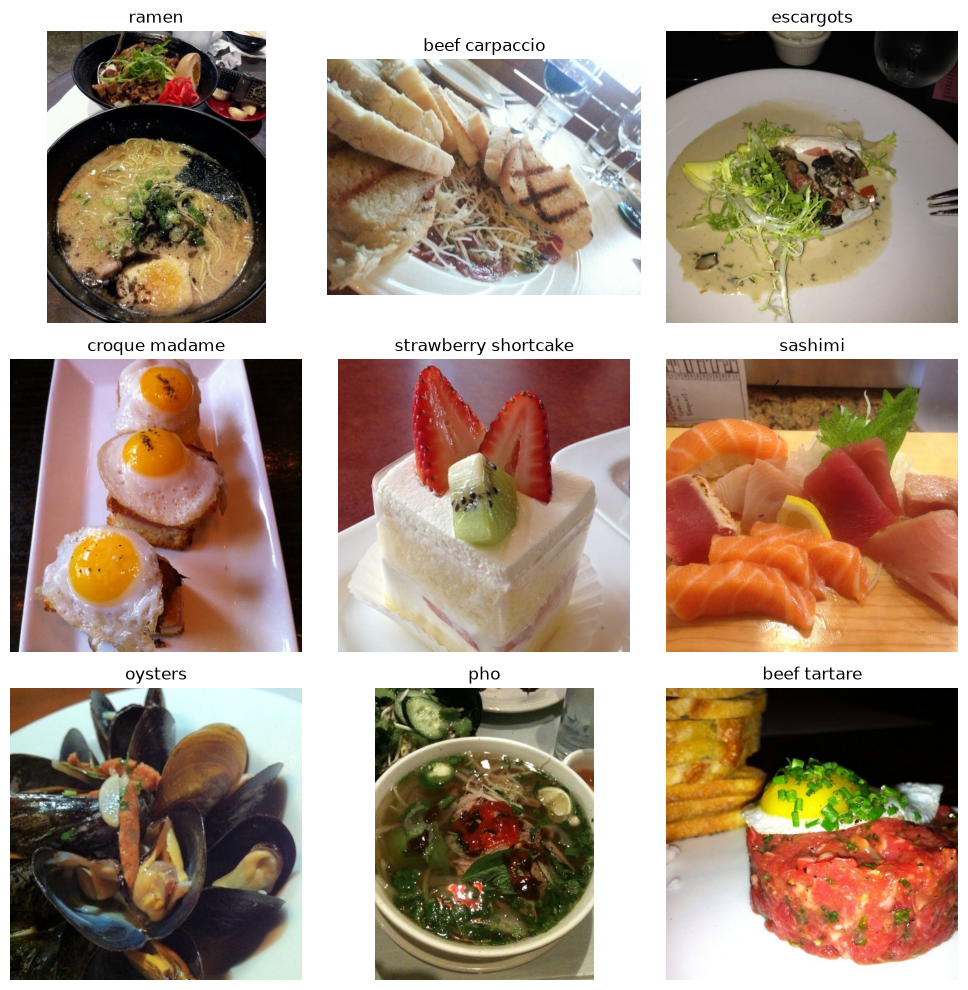

In [10]:
#Random Images
fig, axes = plt.subplots(3,3, figsize=(10,10))

for ax in axes.flat:

    food = random.choice(classes)

    image_path = random.choice(
        list((DATASET_PATH / food).glob("*.jpg"))
    )

    image = Image.open(image_path)

    ax.imshow(image)

    ax.set_title(food.replace("_"," "))

    ax.axis("off")

plt.tight_layout()

plt.savefig(PLOTS_PATH / "sample_images.png")
plt.show()


In [11]:
#Image Resolution Analysis

#We'll check only 20 images per class (2020 images total) for speed.

widths = []

heights = []

for food in tqdm(classes):

    images = list((DATASET_PATH / food).glob("*.jpg"))

    for img in images[:20]:

        image = Image.open(img)

        width, height = image.size

        widths.append(width)

        heights.append(height)

100%|██████████| 101/101 [01:56<00:00,  1.16s/it]


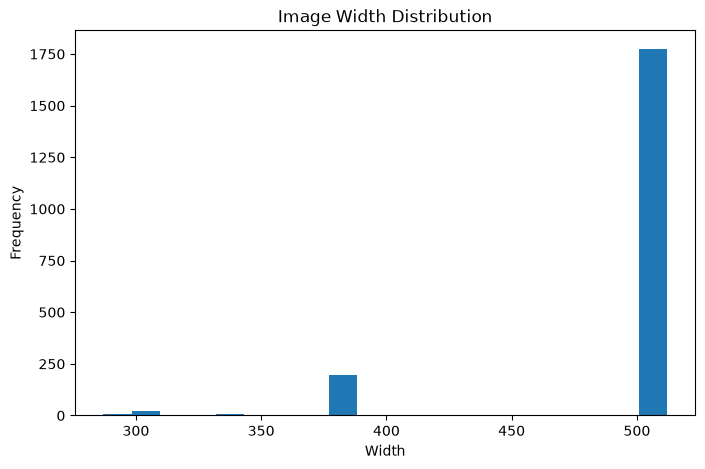

In [12]:
#Width Distribution
plt.figure(figsize=(8,5))

plt.hist(widths, bins=20)

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.savefig(PLOTS_PATH / "image_width_distribution.png")

plt.show()

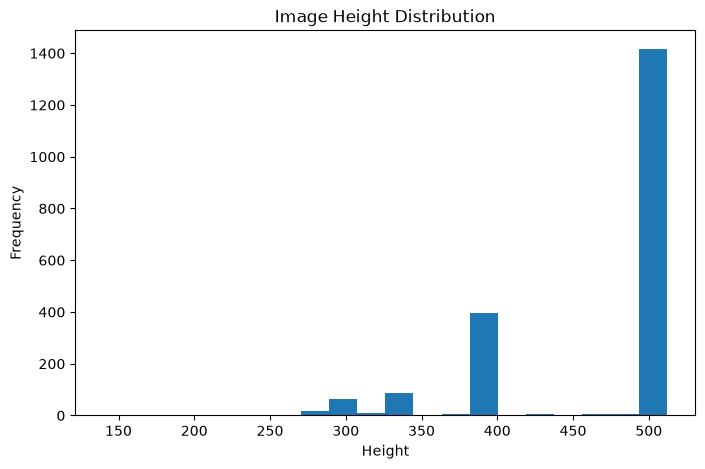

In [13]:
#Height Distribution
plt.figure(figsize=(8,5))

plt.hist(heights, bins=20)

plt.title("Image Height Distribution")

plt.xlabel("Height")

plt.ylabel("Frequency")

plt.savefig(PLOTS_PATH / "image_height_distribution.png")

plt.show()

In [14]:
#Corrupted Image Detection
corrupted = []

for food in tqdm(classes):

    for img in (DATASET_PATH / food).glob("*.jpg"):

        try:

            Image.open(img).verify()

        except:

            corrupted.append(str(img))
            

100%|██████████| 101/101 [38:34<00:00, 22.92s/it]


In [15]:
print("Corrupted Images :", len(corrupted))

Corrupted Images : 0


In [16]:
#Save Results
df.to_csv(
    METRICS_PATH / "class_distribution.csv",
    index=False
)

# Summary

### Key Findings

- Total Food Categories : 101
- Total Images : 101000
- Images per Category : 1000
- Dataset Balance : Balanced
- Corrupted Images : 0
- Image Resolution : Variable

### Conclusion

The Food-101 dataset is balanced and suitable for transfer learning. The next step is image preprocessing and preparing the dataset for deep learning models.